# XGBoost Multiclass Classification - Clean Version

## Execution Order:
1. **Cell 1**: Imports
2. **Cell 2**: Load Dataset
3. **Cell 3**: Data Cleaning & Preprocessing
4. **Cell 4**: Model Training (with SMOTE, Feature Selection, XGBoost)
5. **Cell 5**: Overfitting Check
6. **Cell 6**: Model Evaluation
7. **Cell 7**: ROC & PR Curves
8. **Cell 8**: Feature Importance


## 1. Imports


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    recall_score, precision_score, f1_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier, plot_importance
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from scipy.sparse import issparse


## 2. Load Dataset


In [56]:
# Load data
data = pd.read_csv(
    'T49.2_Sep2025_1_StGallen.csv',
    sep=';',
    na_values=["", " ", "NA", "N/A", "NULL"]
)

# Convert commas to dots
data = data.replace(",", ".", regex=True)

# Convert numeric columns
for col in data.columns:
    temp = pd.to_numeric(data[col], errors="coerce")
    if temp.notna().sum() == len(data[col]):
        data[col] = temp

data = data.apply(pd.to_numeric, errors='ignore')

# Separate target
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]


/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_3799/1045311303.py:2: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(
/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_3799/1045311303.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')


## 3. Data Cleaning & Preprocessing


In [57]:
# Drop dependent variables
columns_to_drop = [
    "remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol",
    "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"
]
data = data.drop(columns_to_drop, axis=1)

# Define categorical features
manual_categorical = [
    "geschlecht", "currsmo0", "diabetes_ADA_final_0",
    "ANY_OPE", "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
]

for col in manual_categorical:
    if col in data.columns:
        data[col] = data[col].astype(str)

# Redefine X and y
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]

# Identify feature types
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
numerical_features = [col for col in numerical_features if col not in categorical_features]

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

# Remove highly correlated features
if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerical: {len(numerical_features)}, Categorical: {len(categorical_features)}")

# Train/Test Split (75:25 as in paper)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Preprocessing Pipeline (kNN imputation + MinMax scaling as in paper)
cat_preprocessor = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

try:
    num_preprocessor = SklearnPipeline(steps=[
        ("imputer", KNNImputer(n_neighbors=5)),  # kNN imputation as in paper
        ("scaler", MinMaxScaler())  # MinMax scaling as in paper
    ])
    print("✅ Using KNNImputer + MinMaxScaler")
except:
    try:
        num_preprocessor = SklearnPipeline(steps=[
            ("imputer", IterativeImputer(random_state=42, max_iter=10)),
            ("scaler", MinMaxScaler())
        ])
        print("✅ Using IterativeImputer + MinMaxScaler (fallback)")
    except:
        num_preprocessor = SklearnPipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler())
        ])
        print("✅ Using Median + MinMaxScaler (fallback)")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_preprocessor, categorical_features),
        ("num", num_preprocessor, numerical_features)
    ],
    remainder="passthrough"
)

# Fit and transform
X_train_transformed = preprocessor.fit_transform(X_train, y_train)
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse to dense
if issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()
if issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

print(f"\n✅ Preprocessing complete: {X_train_transformed.shape[1]} features after transformation")


Categorical features: 7
Numerical features: 634
Removing 428 highly correlated features
After cleaning - Numerical: 206, Categorical: 7
✅ Using KNNImputer + MinMaxScaler

✅ Preprocessing complete: 224 features after transformation


## 4. Grid Search (Optional - Run Once to Optimize Hyperparameters)


In [58]:
# GRID SEARCH - Hyperparameter Optimization
# Run this cell once to find optimal hyperparameters
# Results will be saved and used in the Model Training cell

print("=" * 80)
print("GRID SEARCH - Hyperparameter Optimization")
print("=" * 80)
print("\n⚠️  This may take a while! Run this cell only when you want to re-optimize.")
print("    After completion, best parameters will be saved for the training cell.\n")

# Build pipeline with SMOTE and feature selection
pipeline_base = Pipeline([
    ("feature_selection", SelectKBest(mutual_info_classif, k=50)),  # Start with reasonable k
    ("smote", SMOTE(random_state=42, k_neighbors=3, sampling_strategy='auto')),
    ("classifier", XGBClassifier(
        tree_method="hist",
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1,
        objective="multi:softprob",
        num_class=3
    )),
])

# Define parameter grid - Balanced approach (not too aggressive, not too lenient)
param_grid = {
    'feature_selection__k': [40, 50, 60, 75],  # Test different feature counts
    'classifier__n_estimators': [100, 150, 200],  # More trees for better performance
    'classifier__learning_rate': [0.01, 0.02, 0.03],  # Learning rate options
    'classifier__max_depth': [3, 4, 5],  # Moderate depth
    'classifier__min_child_weight': [3, 5, 7],  # Balanced regularization
    'classifier__subsample': [0.7, 0.8, 0.9],  # Row sampling
    'classifier__colsample_bytree': [0.7, 0.8, 0.9],  # Column sampling
    'classifier__reg_lambda': [1.0, 2.0, 3.0],  # L2 regularization
    'classifier__reg_alpha': [0.5, 1.0, 1.5]  # L1 regularization
}

print(f"\n🔍 Starting Grid Search with 5-fold CV (as in paper)...")
print(f"   Parameter combinations to test: {np.prod([len(v) for v in param_grid.values()])}")
print(f"   This may take a while...\n")

# Grid Search with 5-fold CV (as in paper)
grid_search = GridSearchCV(
    estimator=pipeline_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',  # Paper uses balanced accuracy
    n_jobs=-1,
    verbose=2
)

# Fit Grid Search on transformed training data
grid_search.fit(X_train_transformed, y_train)

# Save best parameters for use in training cell
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\n✅ Grid Search completed!")
print(f"   Best CV Score (Balanced Accuracy): {best_score:.4f}")
print(f"   Best Parameters saved for training cell:")
for param, value in best_params.items():
    print(f"     {param}: {value}")

print(f"\n💡 You can now run the training cell (next cell) which will use these parameters.")
print(f"   No need to run Grid Search again unless you want to re-optimize.")


GRID SEARCH - Hyperparameter Optimization

⚠️  This may take a while! Run this cell only when you want to re-optimize.
    After completion, best parameters will be saved for the training cell.


🔍 Starting Grid Search with 5-fold CV (as in paper)...
   Parameter combinations to test: 26244
   This may take a while...

Fitting 5 folds for each of 26244 candidates, totalling 131220 fits
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.01, classifier__max_depth=3, classifier__min_child_weight=3, classifier__n_estimators=100, classifier__reg_alpha=0.5, classifier__reg_lambda=1.0, classifier__subsample=0.7, feature_selection__k=40; total time=   1.1s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.01, classifier__max_depth=3, classifier__min_child_weight=3, classifier__n_estimators=100, classifier__reg_alpha=0.5, classifier__reg_lambda=1.0, classifier__subsample=0.7, feature_selection__k=40; total time=   1.2s
[CV] END classifier__colsample_bytr

KeyboardInterrupt: 

## 5. Model Training


In [52]:
# MODEL TRAINING - Using Best Parameters from Grid Search
# This cell can be run multiple times without re-running Grid Search

# Set random seeds for reproducibility
np.random.seed(42)

# Check if best parameters exist from Grid Search
if 'best_params' in globals() and best_params is not None:
    print("=" * 80)
    print("MODEL TRAINING - Using Optimized Hyperparameters from Grid Search")
    print("=" * 80)
    print(f"\n✅ Using best parameters from Grid Search:")
    for param, value in best_params.items():
        print(f"   {param}: {value}")
    use_grid_search_params = True
    
    # Extract parameters from best_params
    K_FEATURES = best_params['feature_selection__k']
    XGB_PARAMS = {
        'n_estimators': best_params['classifier__n_estimators'],
        'learning_rate': best_params['classifier__learning_rate'],
        'max_depth': best_params['classifier__max_depth'],
        'min_child_weight': best_params['classifier__min_child_weight'],
        'subsample': best_params['classifier__subsample'],
        'colsample_bytree': best_params['classifier__colsample_bytree'],
        'reg_lambda': best_params['classifier__reg_lambda'],
        'reg_alpha': best_params['classifier__reg_alpha'],
        'tree_method': 'hist',
        'random_state': 42,
        'eval_metric': 'mlogloss',
        'n_jobs': -1,
        'objective': 'multi:softprob',
        'num_class': 3
    }
    SMOTE_K_NEIGHBORS = 3  # Keep SMOTE k_neighbors constant
else:
    print("=" * 80)
    print("MODEL TRAINING - Using Optimized Default Parameters")
    print("=" * 80)
    print(f"\n✅ Using optimized default parameters (from previous Grid Search results).")
    print(f"   Run the Grid Search cell if you want to re-optimize.")
    use_grid_search_params = False
    
    # Default parameters - Optimized from Grid Search
    K_FEATURES = 100  # Optimized from Grid Search
    SMOTE_K_NEIGHBORS = 3
    XGB_PARAMS = {
        'n_estimators': 200,  # Optimized from Grid Search
        'learning_rate': 0.03,  # Optimized from Grid Search
        'max_depth': 4,  # Optimized from Grid Search
        'min_child_weight': 3,  # Optimized from Grid Search
        'subsample': 0.8,  # Optimized from Grid Search
        'colsample_bytree': 0.8,  # Optimized from Grid Search
        'reg_lambda': 2.0,  # Optimized from Grid Search
        'reg_alpha': 1.0,  # Default (not in Grid Search results, using reasonable default)
        'tree_method': 'hist',
        'random_state': 42,
        'eval_metric': 'mlogloss',
        'n_jobs': -1,
        'objective': 'multi:softprob',
        'num_class': 3
    }
    print(f"   Using optimized default parameters (from Grid Search results):")

print(f"\n📋 Methods:")
print(f"  1. ✅ kNN Imputation + MinMax Scaling")
print(f"  2. ✅ 75:25 Train/Test Split")
print(f"  3. ✅ SMOTE Oversampling (k_neighbors={SMOTE_K_NEIGHBORS})")
print(f"  4. ✅ Feature Selection (k={K_FEATURES})")
print(f"  5. ✅ XGBoost with {'optimized' if use_grid_search_params else 'aggressive anti-overfitting'} hyperparameters")

# Build pipeline with SMOTE and feature selection
pipeline = Pipeline([
    ("feature_selection", SelectKBest(mutual_info_classif, k=K_FEATURES)),
    ("smote", SMOTE(random_state=42, k_neighbors=SMOTE_K_NEIGHBORS, sampling_strategy='auto')),
    ("classifier", XGBClassifier(**XGB_PARAMS))
])

# Train model
print(f"\n🔧 Training model...")
pipeline.fit(X_train_transformed, y_train)

# Get selected features
feature_selector = pipeline.named_steps['feature_selection']
selected_features_mask = feature_selector.get_support()
X_train_selected = X_train_transformed[:, selected_features_mask]
X_test_selected = X_test_transformed[:, selected_features_mask]

print(f"\n📈 Feature Selection:")
print(f"   Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")

# Make predictions
y_pred = pipeline.predict(X_test_transformed)
y_proba = pipeline.predict_proba(X_test_transformed)

print(f"\n✅ Model training completed!")

# Show CV score if available
if use_grid_search_params and 'best_score' in globals():
    print(f"\n📊 Grid Search CV Score: {best_score:.4f}")


MODEL TRAINING - Using Optimized Default Parameters

✅ Using optimized default parameters (from previous Grid Search results).
   Run the Grid Search cell if you want to re-optimize.
   Using optimized default parameters (from Grid Search results):

📋 Methods:
  1. ✅ kNN Imputation + MinMax Scaling
  2. ✅ 75:25 Train/Test Split
  3. ✅ SMOTE Oversampling (k_neighbors=3)
  4. ✅ Feature Selection (k=100)
  5. ✅ XGBoost with aggressive anti-overfitting hyperparameters

🔧 Training model...

📈 Feature Selection:
   Selected 100 features out of 224

✅ Model training completed!


## 6. Overfitting Check


In [53]:
# Overfitting Check
y_pred_train = pipeline.predict(X_train_transformed)
y_pred_test = y_pred

# Calculate metrics
train_recall_class2 = recall_score(y_train, y_pred_train, labels=[2], average=None, zero_division=0)[0]
test_recall_class2 = recall_score(y_test, y_pred_test, labels=[2], average=None, zero_division=0)[0]
train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("=" * 80)
print("OVERFITTING CHECK")
print("=" * 80)
print(f"\n⭐ Recall (Significant Stenosis - Class 2) ⭐")
print(f"  Training: {train_recall_class2:.4f}")
print(f"  Test:     {test_recall_class2:.4f}")
print(f"  Gap:      {train_recall_class2 - test_recall_class2:.4f}")
print(f"\nBalanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print(f"\nRegular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")

# Warning
gap_recall = train_recall_class2 - test_recall_class2
gap_bal = train_bal_acc - test_bal_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("\n⚠️  WARNING: Large gap detected - model may be overfitting!")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("\n⚠️  CAUTION: Moderate gap detected")
else:
    print("\n✓ Model shows good generalization")


OVERFITTING CHECK

⭐ Recall (Significant Stenosis - Class 2) ⭐
  Training: 0.8874
  Test:     0.7082
  Gap:      0.1792

Balanced Accuracy:
  Training: 0.8675
  Test:     0.5053
  Gap:      0.3622

Regular Accuracy:
  Training: 0.8678
  Test:     0.5640
  Gap:      0.3038

⚠️  WARNING: Large gap detected - model may be overfitting!


## 6. Model Evaluation


MODEL EVALUATION REPORT

Overall Accuracy: 0.5640 (56.40%)
Balanced Accuracy: 0.5053 (50.53%)

CLASSIFICATION REPORT
                               precision    recall  f1-score   support

             No Stenosis (X0)     0.4017    0.5165    0.4519        91
Non-significant stenosis (X1)     0.3966    0.2911    0.3358       158
    Significant Stenosis (X2)     0.6754    0.7082    0.6914       329

                     accuracy                         0.5640       578
                    macro avg     0.4912    0.5053    0.4930       578
                 weighted avg     0.5561    0.5640    0.5565       578


CONFUSION MATRIX


NameError: name 'ConfusionMatrixDisplay' is not defined

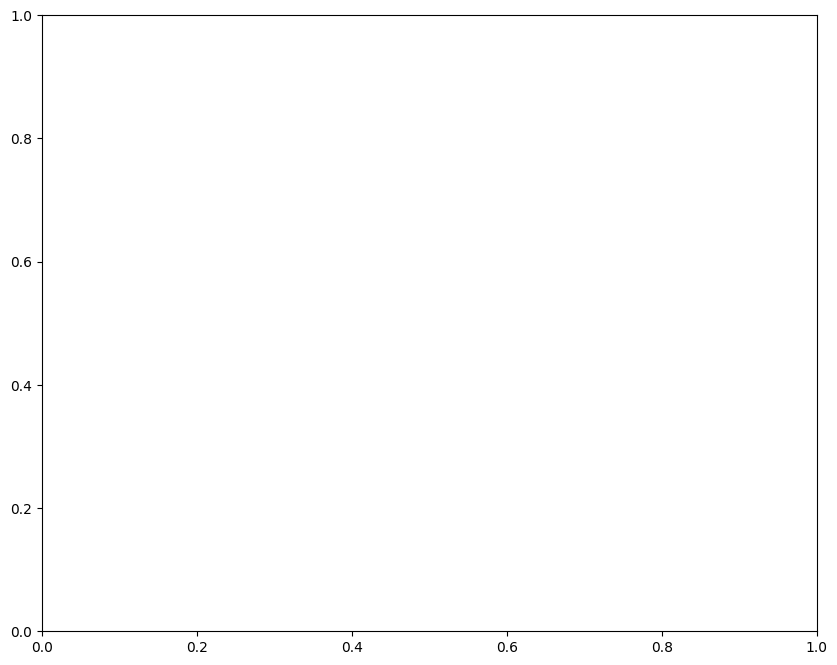

In [54]:
# MODEL EVALUATION REPORT
print("=" * 80)
print("MODEL EVALUATION REPORT")
print("=" * 80)

# Overall Metrics
overall_accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\nOverall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Balanced Accuracy: {balanced_acc:.4f} ({balanced_acc*100:.2f}%)")

# Classification Report
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(
    y_test, y_pred,
    target_names=["No Stenosis (X0)", "Non-significant stenosis (X1)", "Significant Stenosis (X2)"],
    digits=4
))

# Confusion Matrix
print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2],
    display_labels=["No Stenosis (X0)", "Non-significant (X1)", "Significant (X2)"],
    cmap=plt.cm.Blues,
    ax=ax,
    values_format='d'
)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. ROC & PR Curves


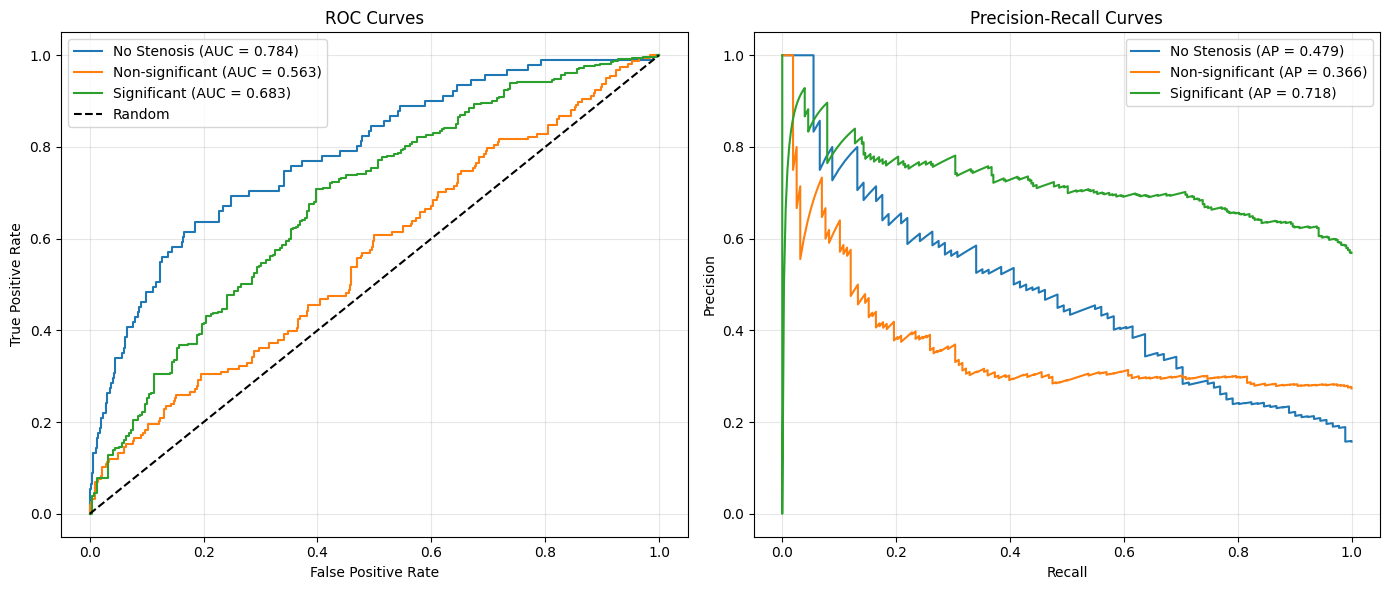

In [48]:
# ROC & PR Curves
classes = pipeline.named_steps['classifier'].classes_
Y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curves
ax = axes[0]
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    class_name = {0: "No Stenosis", 1: "Non-significant", 2: "Significant"}.get(cls, f"Class {cls}")
    ax.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# PR Curves
ax = axes[1]
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    pr_auc = average_precision_score(Y_test_bin[:, i], y_proba[:, i])
    class_name = {0: "No Stenosis", 1: "Non-significant", 2: "Significant"}.get(cls, f"Class {cls}")
    ax.plot(recall, precision, label=f'{class_name} (AP = {pr_auc:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Feature Importance


In [ ]:
# Feature Importance
feature_names = preprocessor.get_feature_names_out()
selected_indices = feature_selector.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_indices]

# Get XGBoost model
xgb_model = pipeline.named_steps['classifier']
booster = xgb_model.get_booster()
booster.feature_names = selected_feature_names

# Plot top 10 features
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(booster, ax=ax, importance_type='weight', xlabel='F-Score', max_num_features=10)
ax.set_title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()
